## 1. Setup and Imports

In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, deque
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# NLP and text processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD

# Machine learning models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Metrics and evaluation
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.model_selection import train_test_split

# Dataset
from datasets import load_dataset

# Set random seed for reproducibility
np.random.seed(42)

# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

print("All libraries imported successfully!")

All libraries imported successfully!


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 2. Load AG News Dataset

In [ ]:
# Load AG News dataset from HuggingFace
print("Loading AG News dataset from HuggingFace...")
dataset = load_dataset("fancyzhx/ag_news")

# Convert to pandas DataFrames
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

# Define class labels
class_names = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
train_df['label_name'] = train_df['label'].map(class_names)
test_df['label_name'] = test_df['label'].map(class_names)

print(f"✓ Dataset loaded successfully!")
print(f"\nTrain set size: {len(train_df):,}")
print(f"Test set size: {len(test_df):,}")
print(f"\nClass labels: {class_names}")
print("\nFirst few samples:")
train_df.head()

Loading AG News dataset from HuggingFace...
✓ Dataset loaded successfully!

Train set size: 120,000
Test set size: 7,600

Class labels: {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

First few samples:


,text,label,label_name
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


## 3. Exploratory Data Analysis (EDA)

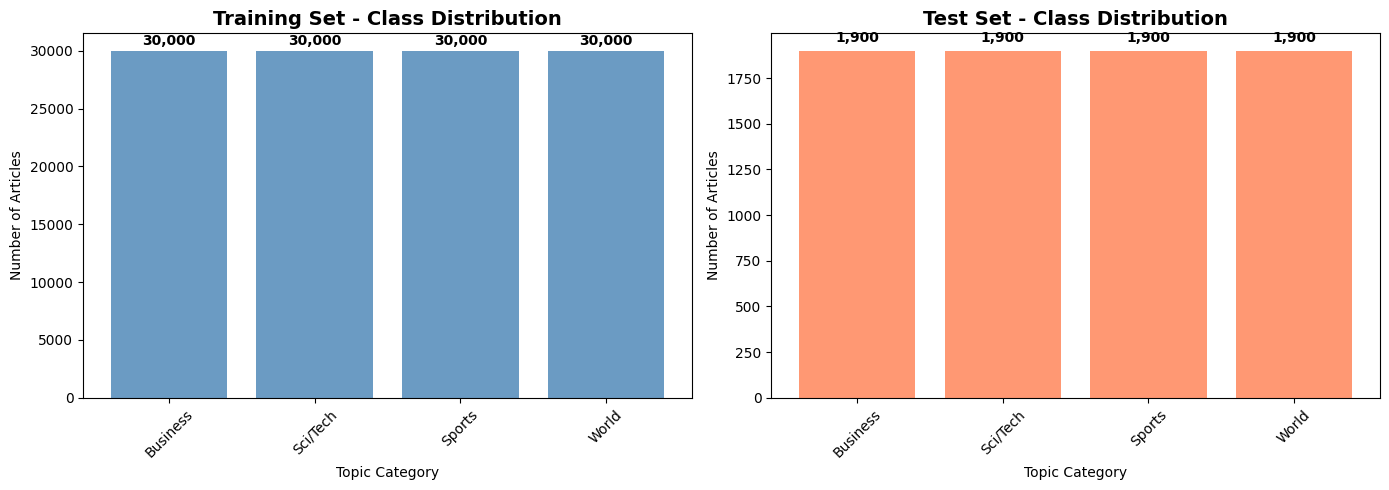

Class Distribution Statistics:

Training Set:
label_name
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64

Test Set:
label_name
Business    1900
Sci/Tech    1900
Sports      1900
World       1900
Name: count, dtype: int64


In [ ]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train set distribution
train_counts = train_df['label_name'].value_counts().sort_index()
axes[0].bar(train_counts.index, train_counts.values, color='steelblue', alpha=0.8)
axes[0].set_title('Training Set - Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Topic Category')
axes[0].set_ylabel('Number of Articles')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Test set distribution
test_counts = test_df['label_name'].value_counts().sort_index()
axes[1].bar(test_counts.index, test_counts.values, color='coral', alpha=0.8)
axes[1].set_title('Test Set - Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Topic Category')
axes[1].set_ylabel('Number of Articles')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Class Distribution Statistics:")
print("\nTraining Set:")
print(train_df['label_name'].value_counts().sort_index())
print("\nTest Set:")
print(test_df['label_name'].value_counts().sort_index())

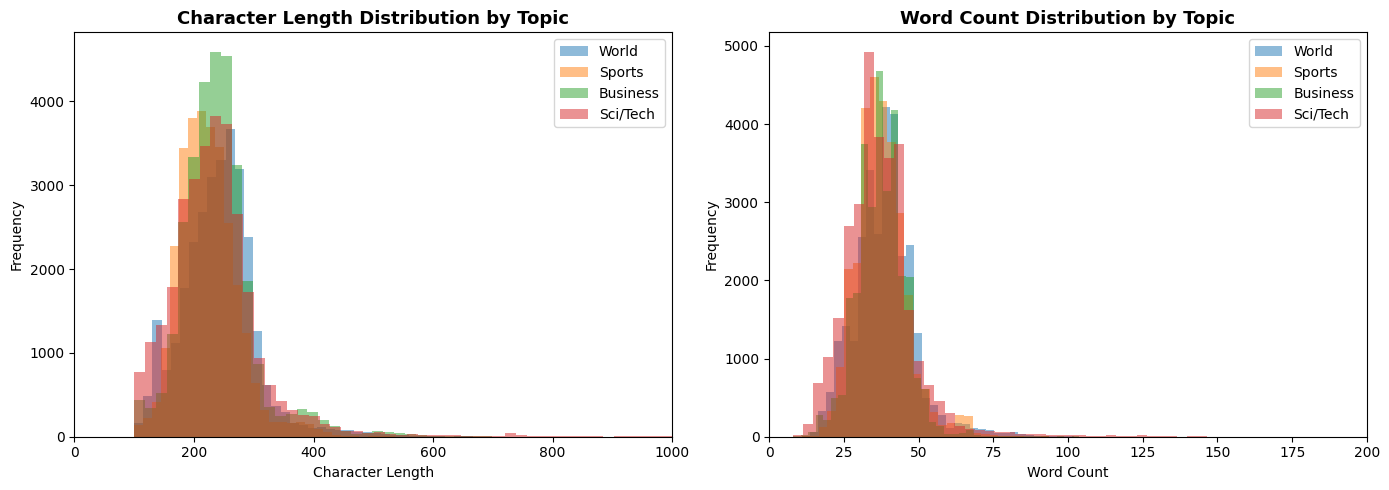


Text Statistics by Topic:
           text_length                                                     \
                 count    mean    std    min    25%    50%    75%     max   
label_name                                                                  
Business       30000.0  241.41  64.26  100.0  204.0  236.0  267.0  1006.0   
Sci/Tech       30000.0  237.22  82.24  100.0  190.0  230.0  268.0  1012.0   
Sports         30000.0  224.65  50.50  100.0  190.0  220.0  251.0   853.0   
World          30000.0  242.63  63.63  100.0  204.0  243.0  276.0   865.0   

           word_count                                               
                count   mean    std   min   25%   50%   75%    max  
label_name                                                          
Business      30000.0  37.54   8.12   8.0  32.0  37.0  42.0  134.0  
Sci/Tech      30000.0  37.19  12.42   8.0  30.0  36.0  42.0  177.0  
Sports        30000.0  37.77   8.87   8.0  32.0  37.0  42.0  151.0  
World         30000

In [ ]:
# Text length analysis
train_df['text_length'] = train_df['text'].str.len()
train_df['word_count'] = train_df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length distribution by class
for label_name in class_names.values():
    subset = train_df[train_df['label_name'] == label_name]
    axes[0].hist(subset['text_length'], bins=50, alpha=0.5, label=label_name)
axes[0].set_title('Character Length Distribution by Topic', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xlim(0, 1000)

# Word count distribution by class
for label_name in class_names.values():
    subset = train_df[train_df['label_name'] == label_name]
    axes[1].hist(subset['word_count'], bins=50, alpha=0.5, label=label_name)
axes[1].set_title('Word Count Distribution by Topic', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_xlim(0, 200)

plt.tight_layout()
plt.show()

print("\nText Statistics by Topic:")
print(train_df.groupby('label_name')[['text_length', 'word_count']].describe().round(2))

## 4. Text Preprocessing (NLP)

In [ ]:
import nltk
nltk.download('all')
# Initialize preprocessing tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Comprehensive text preprocessing pipeline
    - Lowercase conversion
    - Remove special characters and numbers
    - Tokenization
    - Remove stopwords
    - Lemmatization
    """
    # Lowercase
    text = text.lower()

    # Remove special characters, keep only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens
              if token not in stop_words and len(token) > 2]

    return ' '.join(tokens)

# Apply preprocessing
print("Preprocessing training data...")
train_df['text_clean'] = train_df['text'].apply(preprocess_text)

print("Preprocessing test data...")
test_df['text_clean'] = test_df['text'].apply(preprocess_text)

print("\nText preprocessing completed!")
print("\nExample of preprocessing:")
print(f"\nOriginal:\n{train_df.iloc[0]['text'][:200]}...")
print(f"\nCleaned:\n{train_df.iloc[0]['text_clean'][:200]}...")

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

Preprocessing training data...
Preprocessing test data...

Text preprocessing completed!

Example of preprocessing:

Original:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again....

Cleaned:
wall bear claw back black reuters reuters shortsellers wall street dwindlingband ultracynics seeing green...


## 5. Feature Extraction: Converting Text to Numerical Data

In [ ]:
# TF-IDF Vectorization
print("Extracting TF-IDF features...")

# Using TF-IDF with optimized parameters
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,      # Top 10k features
    ngram_range=(1, 2),      # Unigrams and bigrams
    min_df=5,                # Minimum document frequency
    max_df=0.8,              # Maximum document frequency
    sublinear_tf=True        # Apply sublinear tf scaling
)

# Fit on training data and transform both sets
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['text_clean'])
X_test_tfidf = tfidf_vectorizer.transform(test_df['text_clean'])

# Extract labels
y_train = train_df['label'].values
y_test = test_df['label'].values

print(f"\nFeature extraction completed!")
print(f"Training features shape: {X_train_tfidf.shape}")
print(f"Test features shape: {X_test_tfidf.shape}")
print(f"Feature dimensionality: {X_train_tfidf.shape[1]:,} features")
print(f"Sparsity: {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100:.2f}%")

Extracting TF-IDF features...

Feature extraction completed!
Training features shape: (120000, 10000)
Test features shape: (7600, 10000)
Feature dimensionality: 10,000 features
Sparsity: 99.79%
